## <h3 align="center"> __Johns Hopkins University__</h3>
## <h3 align="center">__Whiting School of Engineering__</h3>
## <h3 align="center">__Engineering for Professionals__</h3>
## <h3 align="center">__685.801 Data Science: Independent Study__</h3>
## <h3 align="center">__Serialized Model Results Evaluation__</h3>

---

- **Student:** `Dominick Dimpfel`  
- **Course:** `Data Science: Independent Study`  
- **Date:** `2026-06-21`  
- **Advisors:** `Ben Rodriguez, PhD`, `Amir Saeed`, `Ben Johnson`

---

## README (Execution & Setup)

- **Purpose:** Load JSON files produced by `serialize_save_model_training(...)` and compare continual-learning model behavior without retraining.
- **Expected JSON payload:** `results`, `pred_cache`, and `eval_mat`.
- **Required packages:** `numpy`, `pandas`, `matplotlib`, `seaborn`, `torch`, `pillow`, `scipy`, `statsmodels`.
- **How to use:**
  1. Update the results path configuration in Cell 6.
  2. Run the notebook top to bottom.
  3. Use the summary, submodel comparison, significance-test, and figure sections to analyze saved runs without retraining.

---

In [1]:
! pip install -q numpy pandas matplotlib seaborn torch pillow scipy statsmodels

In [2]:
# Environment Check
import sys, platform
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
try:
    import numpy as np, pandas as pd, matplotlib, seaborn, scipy, statsmodels, torch
    from PIL import Image
    print(f"numpy:      {np.__version__}")
    print(f"pandas:     {pd.__version__}")
    print(f"matplotlib: {matplotlib.__version__}")
    print(f"seaborn:    {getattr(seaborn, '__version__', 'unknown')}")
    print(f"scipy:      {scipy.__version__}")
    print(f"statsmodels:{statsmodels.__version__}")
    print(f"pytorch:    {torch.__version__}")
    print(f"pillow:     {Image.__version__}")
except Exception as e:
    print("Optional packages missing or version check failed:", e)
    print("Use the command in the cell above to install necessary packages.")

Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
numpy:      2.0.2
pandas:     2.2.2
matplotlib: 3.10.0
seaborn:    0.13.2
scipy:      1.16.3
statsmodels:0.14.6
pytorch:    2.11.0+cpu
pillow:     11.3.0


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import kagglehub

import numpy as np
import pandas as pd
from IPython.display import display

from plots import (
    reset_figure_number,
    load_serialized_training_runs,
    build_serialized_results_table,
    build_transfer_table,
    build_forgetting_table,
    build_training_time_table,
    plot_metric_bar,
    plot_metric_scatter,
    plot_transfer_curves,
    plot_training_time_per_stage,
    plot_eval_matrix_heatmap,
 )

## Load GTSRB for Visualizations

Required with Colab paths to images serialized in results.

In [4]:
# From HW1 Problem 1a code:
GTSRB_DATASET_NAME = "meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
csv_paths: dict[str, Path | None] = {
    "train.csv": None,
    "test.csv": None,
    "meta.csv": None
}

# --- Download latest from Kaggle ---
download_dir = Path(kagglehub.dataset_download(GTSRB_DATASET_NAME))

# 1) Exact match (case-insensitive)
for csv in download_dir.rglob("*.csv"):
    if csv.name.lower() in {n.lower() for n in csv_paths}:
        csv_paths[csv.name.lower()] = csv

print("Kaggle dataset directory:", str(download_dir))
for name, path in csv_paths.items():
    print(f"Resolved {name} path: {path}")

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Kaggle dataset directory: /kaggle/input/gtsrb-german-traffic-sign
Resolved train.csv path: /kaggle/input/gtsrb-german-traffic-sign/Train.csv
Resolved test.csv path: /kaggle/input/gtsrb-german-traffic-sign/Test.csv
Resolved meta.csv path: /kaggle/input/gtsrb-german-traffic-sign/Meta.csv


## Locate Serialized Results

Point this notebook at the JSON files produced by `serialize_save_model_training(...)`. Use either an explicit file list or a directory plus glob pattern.

In [5]:
RESULTS_DIR = Path('./')
RESULT_GLOB = '**/*.json'

all_paths = sorted(RESULTS_DIR.glob(RESULT_GLOB))
result_paths = [path for path in all_paths if " + " in str(path)]
if not result_paths:
    raise FileNotFoundError('No JSON files were found. Update RESULTS_DIR or RESULT_GLOB before continuing.')

pd.DataFrame({'Result File': [str(path) for path in result_paths]})

,Result File
0,ConvNeXt + Layered Router + MLP Experts_2026-0...
1,ConvNeXt + Layered Router + ResMLP Experts_202...
2,ConvNeXt + Layered Router + Transformer Expert...
3,ConvNeXt + MLP Router + MLP Experts_2026-06-28...
4,ConvNeXt + MLP Router + ResMLP Experts_2026-06...
5,ConvNeXt + MLP Router + Transformer Experts_20...
6,MobileNet + Layered Router + MLP Experts_2026-...
7,MobileNet + Layered Router + ResMLP Experts_20...
8,MobileNet + Layered Router + Transformer Exper...
9,MobileNet + MLP Router + MLP Experts_2026-06-2...


In [6]:
runs = load_serialized_training_runs(result_paths)
comparison_df = build_serialized_results_table(runs)

primary_metric = 'AvgAcc Micro F1'
primary_bwt_metric = 'Backward Transfer Micro F1'
primary_fwt_metric = 'Forward Transfer Micro F1'
primary_forgetting_metric = 'Average Forgetting Micro F1'
primary_validation_metric = 'Full Validation Micro F1'

summary_columns = [
    column for column in [
        'Model',
        primary_metric,
        primary_bwt_metric,
        primary_fwt_metric,
        primary_forgetting_metric,
        primary_validation_metric,
        'Post Training ECE',
        'Post Training Router Entropy',
        'Post Training Expected Expert Calls',
        'Total Compute Time (s)',
        'Num Parameters',
    ] if column in comparison_df.columns
]
summary_df = comparison_df.loc[:, summary_columns].copy()
summary_df = summary_df.sort_values(
    by=[primary_metric, primary_validation_metric],
    ascending=False,
).reset_index(drop=True)

display(summary_df.style.format({
    primary_metric: '{:.4f}',
    primary_bwt_metric: '{:.4f}',
    primary_fwt_metric: '{:.4f}',
    primary_forgetting_metric: '{:.4f}',
    primary_validation_metric: '{:.4f}',
    'Post Training ECE': '{:.4f}',
    'Post Training Router Entropy': '{:.4f}',
    'Post Training Expected Expert Calls': '{:.4f}',
    'Total Compute Time (s)': '{:.1f}',
    'Num Parameters': '{:,.0f}',
}))

insight_df = comparison_df.copy()
if {'Baseline Accuracy', primary_metric}.issubset(insight_df.columns):
    insight_df['Retention Ratio'] = np.where(
        insight_df['Baseline Accuracy'] > 0,
        insight_df[primary_metric] / insight_df['Baseline Accuracy'],
        np.nan,
    )
if {primary_metric, 'Total Compute Time (s)'}.issubset(insight_df.columns):
    insight_df['Accuracy per Compute Second'] = np.where(
        insight_df['Total Compute Time (s)'] > 0,
        insight_df[primary_metric] / insight_df['Total Compute Time (s)'],
        np.nan,
    )
if {primary_validation_metric, primary_metric}.issubset(insight_df.columns):
    insight_df['Validation Lift'] = insight_df[primary_validation_metric] - insight_df[primary_metric]

insight_columns = [
    column for column in [
        'Model',
        primary_metric,
        primary_validation_metric,
        primary_forgetting_metric,
        'Retention Ratio',
        'Accuracy per Compute Second',
        'Validation Lift',
        'Total Compute Time (s)',
        'Num Parameters',
    ] if column in insight_df.columns
]

display(
    insight_df.loc[:, insight_columns]
    .sort_values(by=[primary_metric, primary_validation_metric], ascending=False)
    .style.format({
        primary_metric: '{:.4f}',
        primary_validation_metric: '{:.4f}',
        primary_forgetting_metric: '{:.4f}',
        'Retention Ratio': '{:.4f}',
        'Accuracy per Compute Second': '{:.6f}',
        'Validation Lift': '{:.4f}',
        'Total Compute Time (s)': '{:.1f}',
        'Num Parameters': '{:,.0f}',
    })
)

,Model,AvgAcc Micro F1,Backward Transfer Micro F1,Forward Transfer Micro F1,Average Forgetting Micro F1,Full Validation Micro F1,Post Training ECE,Post Training Router Entropy,Post Training Expected Expert Calls,Total Compute Time (s),Num Parameters
0,ConvNeXt + Layered Router + MLP Experts_2026-06-28,0.9486,-0.0632,-0.1280,0.0632,0.9470,0.0084,0.1365,2.0000,1411.3,"29,615,008"
1,ConvNeXt + MLP Router + MLP Experts_2026-06-28,0.9407,-0.0812,-0.1208,0.0812,0.9380,0.0176,1.5120,2.0000,1363.4,"28,429,216"
2,MobileNet + Layered Router + Transformer Experts_2026-06-28,0.9390,-0.0874,-0.0555,0.0874,0.9355,0.0489,0.6749,2.0000,332.1,"2,434,866"
3,ConvNeXt + MLP Router + Transformer Experts_2026-06-28,0.9318,-0.0876,-0.0812,0.0876,0.9290,0.0163,0.9320,2.0000,1370.3,"28,663,840"
4,MobileNet + MLP Router + MLP Experts_2026-06-28,0.9254,-0.1041,-0.1502,0.1041,0.9215,0.0344,1.5797,2.0000,364.8,"1,385,778"
5,MobileNet + MLP Router + Transformer Experts_2026-06-28,0.9230,-0.1111,-0.0260,0.1111,0.9187,0.0504,1.3501,2.0000,341.0,"1,766,706"
6,ConvNeXt + Layered Router + Transformer Experts_2026-06-28,0.9171,-0.1063,-0.1441,0.1063,0.9140,0.0246,0.7448,2.0000,1365.6,"29,849,632"
7,MobileNet + Layered Router + ResMLP Experts_2026-06-28,0.9156,-0.1204,-0.1201,0.1204,0.9109,0.0116,1.3338,2.0000,321.8,"2,460,210"
8,MobileNet + Layered Router + MLP Experts_2026-06-28,0.9127,-0.1200,-0.1253,0.1200,0.9084,0.0107,1.3361,2.0000,313.0,"2,053,938"
9,ConvNeXt + Layered Router + ResMLP Experts_2026-06-28,0.9051,-0.1301,-0.1681,0.1301,0.9003,0.0256,0.0433,2.0000,1358.7,"30,023,584"


,Model,AvgAcc Micro F1,Full Validation Micro F1,Average Forgetting Micro F1,Retention Ratio,Accuracy per Compute Second,Validation Lift,Total Compute Time (s),Num Parameters
0,ConvNeXt + Layered Router + MLP Experts_2026-06-28,0.9486,0.9470,0.0632,0.9486,0.000672,-0.0016,1411.3,"29,615,008"
3,ConvNeXt + MLP Router + MLP Experts_2026-06-28,0.9407,0.9380,0.0812,0.9407,0.000690,-0.0027,1363.4,"28,429,216"
8,MobileNet + Layered Router + Transformer Experts_2026-06-28,0.9390,0.9355,0.0874,0.9390,0.002828,-0.0035,332.1,"2,434,866"
5,ConvNeXt + MLP Router + Transformer Experts_2026-06-28,0.9318,0.9290,0.0876,0.9318,0.000680,-0.0028,1370.3,"28,663,840"
9,MobileNet + MLP Router + MLP Experts_2026-06-28,0.9254,0.9215,0.1041,0.9254,0.002537,-0.0040,364.8,"1,385,778"
11,MobileNet + MLP Router + Transformer Experts_2026-06-28,0.9230,0.9187,0.1111,0.9230,0.002706,-0.0043,341.0,"1,766,706"
2,ConvNeXt + Layered Router + Transformer Experts_2026-06-28,0.9171,0.9140,0.1063,0.9171,0.000672,-0.0030,1365.6,"29,849,632"
7,MobileNet + Layered Router + ResMLP Experts_2026-06-28,0.9156,0.9109,0.1204,0.9156,0.002845,-0.0047,321.8,"2,460,210"
6,MobileNet + Layered Router + MLP Experts_2026-06-28,0.9127,0.9084,0.1200,0.9127,0.002916,-0.0043,313.0,"2,053,938"
1,ConvNeXt + Layered Router + ResMLP Experts_2026-06-28,0.9051,0.9003,0.1301,0.9084,0.000666,-0.0048,1358.7,"30,023,584"


In [7]:
transfer_df = build_transfer_table(comparison_df, suffix='Micro F1')
forgetting_df = build_forgetting_table(comparison_df, suffix='Micro F1')
training_time_df = build_training_time_table(comparison_df)

if not transfer_df.empty:
    display(transfer_df.style.format({
        'Backward Transfer': '{:.4f}',
        'Forward Transfer': '{:.4f}',
    }))

if not forgetting_df.empty:
    display(forgetting_df.style.format({'Forgetting': '{:.4f}'}))

if not training_time_df.empty:
    display(training_time_df.style.format({'Training Time (s)': '{:.2f}'}))

,Model,Short Label,Task Pair,Backward Transfer,Forward Transfer
0,ConvNeXt + Layered Router + MLP Experts_2026-06-28,ConvNeXtLRME,Task 1 -> Task 2,-0.0281,-0.2252
1,ConvNeXt + Layered Router + MLP Experts_2026-06-28,ConvNeXtLRME,Task 2 -> Task 3,-0.0984,-0.0308
2,ConvNeXt + Layered Router + ResMLP Experts_2026-06-28,ConvNeXtLRRE,Task 1 -> Task 2,-0.1219,-0.0018
3,ConvNeXt + Layered Router + ResMLP Experts_2026-06-28,ConvNeXtLRRE,Task 2 -> Task 3,-0.1383,-0.3344
4,ConvNeXt + Layered Router + Transformer Experts_2026-06-28,ConvNeXtLRTE,Task 1 -> Task 2,-0.0246,-0.0567
5,ConvNeXt + Layered Router + Transformer Experts_2026-06-28,ConvNeXtLRTE,Task 2 -> Task 3,-0.1879,-0.2314
6,ConvNeXt + MLP Router + MLP Experts_2026-06-28,ConvNeXtMRME,Task 1 -> Task 2,-0.0605,-0.1046
7,ConvNeXt + MLP Router + MLP Experts_2026-06-28,ConvNeXtMRME,Task 2 -> Task 3,-0.1020,-0.1369
8,ConvNeXt + MLP Router + ResMLP Experts_2026-06-28,ConvNeXtMRRE,Task 1 -> Task 2,-0.0553,-0.2766
9,ConvNeXt + MLP Router + ResMLP Experts_2026-06-28,ConvNeXtMRRE,Task 2 -> Task 3,-0.1933,-0.0297


,Model,Short Label,Task,Forgetting
0,ConvNeXt + Layered Router + MLP Experts_2026-06-28,ConvNeXtLRME,Task 1,0.0281
1,ConvNeXt + Layered Router + MLP Experts_2026-06-28,ConvNeXtLRME,Task 2,0.0984
2,ConvNeXt + Layered Router + ResMLP Experts_2026-06-28,ConvNeXtLRRE,Task 1,0.1219
3,ConvNeXt + Layered Router + ResMLP Experts_2026-06-28,ConvNeXtLRRE,Task 2,0.1383
4,ConvNeXt + Layered Router + Transformer Experts_2026-06-28,ConvNeXtLRTE,Task 1,0.0246
5,ConvNeXt + Layered Router + Transformer Experts_2026-06-28,ConvNeXtLRTE,Task 2,0.1879
6,ConvNeXt + MLP Router + MLP Experts_2026-06-28,ConvNeXtMRME,Task 1,0.0605
7,ConvNeXt + MLP Router + MLP Experts_2026-06-28,ConvNeXtMRME,Task 2,0.1020
8,ConvNeXt + MLP Router + ResMLP Experts_2026-06-28,ConvNeXtMRRE,Task 1,0.0553
9,ConvNeXt + MLP Router + ResMLP Experts_2026-06-28,ConvNeXtMRRE,Task 2,0.1933


,Model,Short Label,Stage,Training Time (s)
0,ConvNeXt + Layered Router + MLP Experts_2026-06-28,ConvNeXtLRME,Stage 1,421.51
1,ConvNeXt + Layered Router + MLP Experts_2026-06-28,ConvNeXtLRME,Stage 2,519.61
2,ConvNeXt + Layered Router + MLP Experts_2026-06-28,ConvNeXtLRME,Stage 3,470.14
3,ConvNeXt + Layered Router + ResMLP Experts_2026-06-28,ConvNeXtLRRE,Stage 1,402.31
4,ConvNeXt + Layered Router + ResMLP Experts_2026-06-28,ConvNeXtLRRE,Stage 2,502.43
5,ConvNeXt + Layered Router + ResMLP Experts_2026-06-28,ConvNeXtLRRE,Stage 3,453.94
6,ConvNeXt + Layered Router + Transformer Experts_2026-06-28,ConvNeXtLRTE,Stage 1,404.74
7,ConvNeXt + Layered Router + Transformer Experts_2026-06-28,ConvNeXtLRTE,Stage 2,504.24
8,ConvNeXt + Layered Router + Transformer Experts_2026-06-28,ConvNeXtLRTE,Stage 3,456.63
9,ConvNeXt + MLP Router + MLP Experts_2026-06-28,ConvNeXtMRME,Stage 1,405.57


## Primary Accuracy Comparison

This section focuses on `AvgAcc Micro F1` as the primary saved-run comparison metric and highlights one stage-wise misprediction for the MobileNet + MLP Router + MLP Experts model.

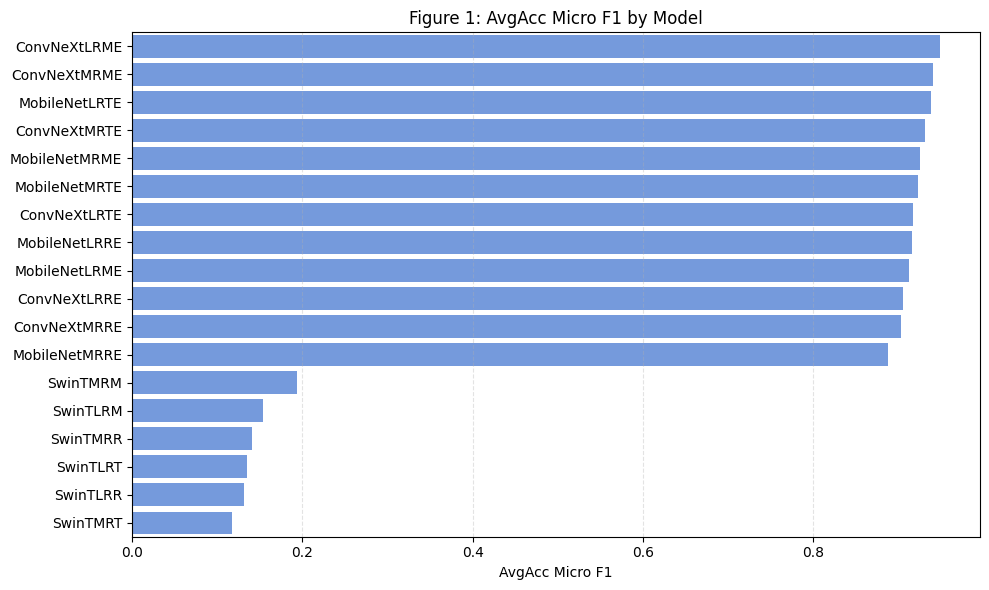

In [8]:
reset_figure_number(1)

if 'AvgAcc Micro F1' in comparison_df.columns:
    plot_metric_bar(comparison_df, 'AvgAcc Micro F1')

### F1 Score Formulas

For class $c$, let $TP_c$, $FP_c$, and $FN_c$ denote true positives, false positives, and false negatives. Precision and recall are:

$$
\mathrm{Precision}_c = \frac{TP_c}{TP_c + FP_c}
$$

$$
\mathrm{Recall}_c = \frac{TP_c}{TP_c + FN_c}
$$

The class-wise F1 score is the harmonic mean of precision and recall:

$$
F1_c = \frac{2\,\mathrm{Precision}_c\,\mathrm{Recall}_c}{\mathrm{Precision}_c + \mathrm{Recall}_c} = \frac{2TP_c}{2TP_c + FP_c + FN_c}
$$

Using the three saved F1 scoring variants in this project:

$$
F1_{\text{macro}} = \frac{1}{C}\sum_{c=1}^{C} F1_c
$$

- Good for imbalanced datasets where every class is present in the task sample.

$$
F1_{\text{weighted}} = \sum_{c=1}^{C} \frac{n_c}{N} F1_c
$$

- Good for imbalanced datasets where every class is present in the task sample.

$$
F1_{\text{micro}} = \frac{2\sum_{c=1}^{C} TP_c}{2\sum_{c=1}^{C} TP_c + \sum_{c=1}^{C} FP_c + \sum_{c=1}^{C} FN_c}
$$

- Good for partially imbalanced datasets where every sample amtters.

where $C$ is the number of classes, $n_c$ is the support for class $c$, and $N = \sum_{c=1}^{C} n_c$ is the total number of labeled examples.

,Model,AvgAcc Micro F1,AvgAcc Macro F1,AvgAcc Weighted F1,AvgAcc Macro F1 - AvgAcc Micro F1,AvgAcc Weighted F1 - AvgAcc Micro F1
0,ConvNeXt + Layered Router + MLP Experts_2026-06-28,0.9486,0.4957,0.9706,-0.4530,+0.0219
1,ConvNeXt + MLP Router + MLP Experts_2026-06-28,0.9407,0.4713,0.9664,-0.4694,+0.0257
2,MobileNet + Layered Router + Transformer Experts_2026-06-28,0.9390,0.5871,0.9659,-0.3519,+0.0270
3,ConvNeXt + MLP Router + Transformer Experts_2026-06-28,0.9318,0.4732,0.9599,-0.4586,+0.0281
4,MobileNet + MLP Router + MLP Experts_2026-06-28,0.9254,0.4607,0.9574,-0.4647,+0.0320
5,MobileNet + MLP Router + Transformer Experts_2026-06-28,0.9230,0.5221,0.9553,-0.4009,+0.0323
6,ConvNeXt + Layered Router + Transformer Experts_2026-06-28,0.9171,0.4259,0.9465,-0.4912,+0.0295
7,MobileNet + Layered Router + ResMLP Experts_2026-06-28,0.9156,0.4985,0.9515,-0.4171,+0.0359
8,MobileNet + Layered Router + MLP Experts_2026-06-28,0.9127,0.4689,0.9490,-0.4438,+0.0363
9,ConvNeXt + Layered Router + ResMLP Experts_2026-06-28,0.9051,0.4838,0.9447,-0.4213,+0.0397


,Model,AvgAcc Micro F1,AvgAcc Macro F1,AvgAcc Weighted F1
0,ConvNeXt + Layered Router + MLP Experts_2026-06-28,1,5,1
1,ConvNeXt + MLP Router + MLP Experts_2026-06-28,2,9,2
2,MobileNet + Layered Router + Transformer Experts_2026-06-28,3,1,3
3,ConvNeXt + MLP Router + Transformer Experts_2026-06-28,4,8,4
4,MobileNet + MLP Router + MLP Experts_2026-06-28,5,11,5
5,MobileNet + MLP Router + Transformer Experts_2026-06-28,6,2,6
6,ConvNeXt + Layered Router + Transformer Experts_2026-06-28,7,12,9
7,MobileNet + Layered Router + ResMLP Experts_2026-06-28,8,4,7
8,MobileNet + Layered Router + MLP Experts_2026-06-28,9,10,8
9,ConvNeXt + Layered Router + ResMLP Experts_2026-06-28,10,6,10


,Metric,Mean Across Models,Std Across Models,Min,Max
0,AvgAcc Micro F1,0.6623,0.3662,0.1171,0.9486
1,AvgAcc Macro F1,0.3656,0.1773,0.0963,0.5871
2,AvgAcc Weighted F1,0.6809,0.3860,0.0882,0.9706


/tmp/ipykernel_2358/4020149147.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


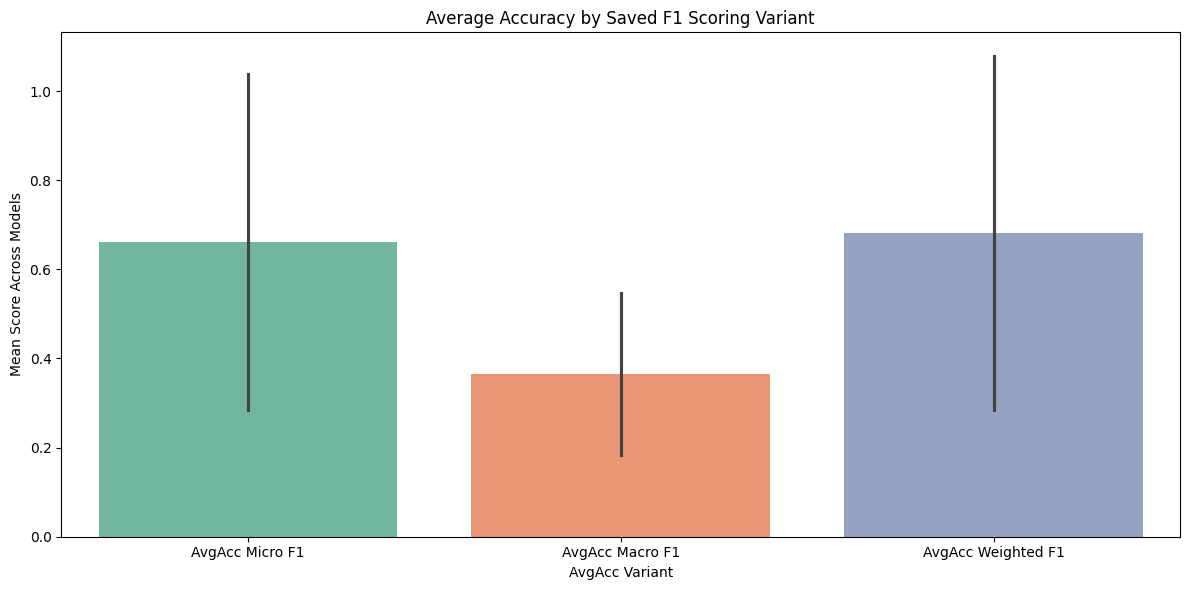

In [ ]:
# Compare the available average-accuracy variants per model
avgacc_metric_candidates = [
    'AvgAcc',
    'AvgAcc Macro F1',
    'AvgAcc Micro F1',
    'AvgAcc Weighted F1',
]
available_avgacc_metrics = [
    metric for metric in avgacc_metric_candidates
    if metric in comparison_df.columns
 and metric != 'Model'
 ]

# Avoid showing the legacy duplicate column if it matches explicit macro values
if {'AvgAcc', 'AvgAcc Macro F1'}.issubset(comparison_df.columns):
    if np.allclose(
        comparison_df['AvgAcc'].to_numpy(dtype=float),
        comparison_df['AvgAcc Macro F1'].to_numpy(dtype=float),
        equal_nan=True,
    ):
        available_avgacc_metrics = [
            metric for metric in available_avgacc_metrics
            if metric != 'AvgAcc'
        ]

# Always keep Micro-F1 first for the notebook's primary comparison lens
preferred_metric_order = [
    'AvgAcc Micro F1',
    'AvgAcc Macro F1',
    'AvgAcc Weighted F1',
    'AvgAcc',
]
available_avgacc_metrics = [
    metric for metric in preferred_metric_order
    if metric in available_avgacc_metrics
 ]

# Model-level comparison table
avgacc_comparison_df = comparison_df[['Model', *available_avgacc_metrics]].copy()
avgacc_comparison_df = avgacc_comparison_df.sort_values(
    by=available_avgacc_metrics[0],
    ascending=False,
).reset_index(drop=True)

# Add deltas versus Micro-F1 when those alternatives exist
if 'AvgAcc Micro F1' in avgacc_comparison_df.columns:
    for metric in available_avgacc_metrics:
        if metric == 'AvgAcc Micro F1':
            continue
        avgacc_comparison_df[f'{metric} - AvgAcc Micro F1'] = (
            avgacc_comparison_df[metric] - avgacc_comparison_df['AvgAcc Micro F1']
        )

# Aggregate comparison across scoring variants
avgacc_summary_df = pd.DataFrame({
    'Metric': available_avgacc_metrics,
    'Mean Across Models': [comparison_df[metric].mean() for metric in available_avgacc_metrics],
    'Std Across Models': [comparison_df[metric].std(ddof=0) for metric in available_avgacc_metrics],
    'Min': [comparison_df[metric].min() for metric in available_avgacc_metrics],
    'Max': [comparison_df[metric].max() for metric in available_avgacc_metrics],
})

# Styling
avgacc_formatters = {metric: '{:.4f}' for metric in available_avgacc_metrics}
for metric in available_avgacc_metrics:
    delta_col = f'{metric} - AvgAcc Micro F1'
    if delta_col in avgacc_comparison_df.columns:
        avgacc_formatters[delta_col] = '{:+.4f}'

# Show tables
display(avgacc_comparison_df.style.format(avgacc_formatters))

# Average ranking consistency across metrics
rank_columns = {
    metric: avgacc_comparison_df[metric].rank(ascending=False, method='min')
    for metric in available_avgacc_metrics
}
rank_df = pd.DataFrame({'Model': avgacc_comparison_df['Model'], **rank_columns})
display(rank_df.style.format({metric: '{:.0f}' for metric in available_avgacc_metrics}))

# Aggregate summary and figure
display(avgacc_summary_df.style.format({
    'Mean Across Models': '{:.4f}',
    'Std Across Models': '{:.4f}',
    'Min': '{:.4f}',
    'Max': '{:.4f}',
}))

# Visual comparison of the different AvgAcc variants
avgacc_long_df = avgacc_comparison_df.melt(
    id_vars='Model',
    value_vars=available_avgacc_metrics,
    var_name='AvgAcc Variant',
    value_name='Score',
)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=avgacc_long_df,
    x='AvgAcc Variant',
    y='Score',
    estimator=np.mean,
    palette='Set2',
)
plt.title('Average Accuracy by Saved F1 Scoring Variant')
plt.xlabel('AvgAcc Variant')
plt.ylabel('Mean Score Across Models')
plt.tight_layout()
plt.show()

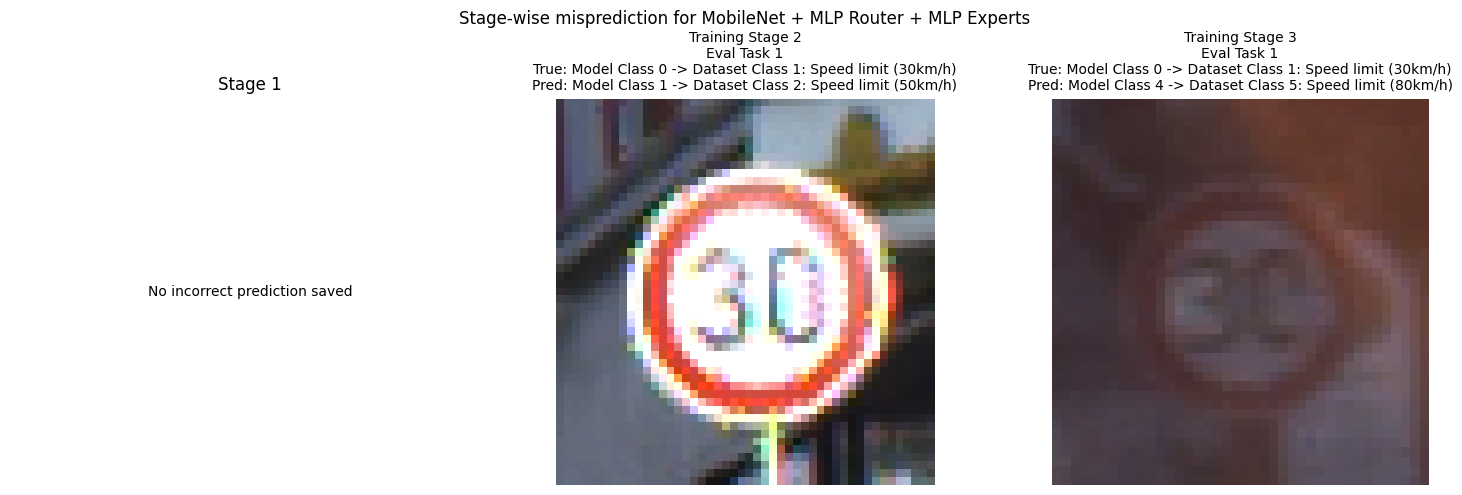

In [10]:
SIGNNAMES_URL = 'https://raw.githubusercontent.com/georgesung/traffic_sign_classification_german/master/signnames.csv'

PROHIBITORY_SIGN_CLASSES = [class_id for class_id in range(1, 11) if class_id != 6]
MODEL_TO_DATASET_CLASS = {
    model_class: dataset_class
    for model_class, dataset_class in enumerate(sorted(PROHIBITORY_SIGN_CLASSES))
}

def _load_class_label_map():
    try:
        class_name_df = pd.read_csv(SIGNNAMES_URL)
        return dict(zip(class_name_df['ClassId'], class_name_df['SignName']))
    except Exception:
        return {}

def _resolve_saved_class_label(class_id: int, class_label_map: dict[int, str]):
    dataset_class_id = MODEL_TO_DATASET_CLASS.get(class_id, class_id)
    sign_name = class_label_map.get(dataset_class_id)
    if sign_name is None:
        return f'Model Class {class_id} -> Dataset Class {dataset_class_id}'
    return f'Model Class {class_id} -> Dataset Class {dataset_class_id}: {sign_name}'

def plot_stagewise_misprediction_for_run(run, download_base_path, sample_index=0):
    pred_cache = run.get('pred_cache', {})
    if not pred_cache:
        raise ValueError('This serialized run does not contain prediction cache entries.')

    class_label_map = _load_class_label_map()
    stage_keys = sorted({key[0] for key in pred_cache if isinstance(key, tuple) and len(key) == 2})
    if not stage_keys:
        raise ValueError('No stage-indexed prediction cache keys were found.')

    fig, axes = plt.subplots(1, len(stage_keys), figsize=(5 * len(stage_keys), 5))
    if len(stage_keys) == 1:
        axes = [axes]

    for ax, stage_index in zip(axes, stage_keys):
        stage_entries = sorted(
            [key for key in pred_cache if isinstance(key, tuple) and len(key) == 2 and key[0] == stage_index],
            key=lambda item: item[1],
        )

        chosen = None
        for cache_key in stage_entries:
            entry = pred_cache[cache_key]
            if not isinstance(entry, dict):
                continue
            logits = np.asarray(entry.get('logits', []))
            targets = np.asarray(entry.get('targets', []))
            paths = entry.get('paths') or []
            if logits.size == 0 or targets.size == 0:
                continue
            preds = np.argmax(logits, axis=1)
            wrong_indices = np.flatnonzero(preds != targets)
            if wrong_indices.size == 0:
                continue
            selected_index = wrong_indices[min(sample_index, wrong_indices.size - 1)]
            chosen = (cache_key[1], selected_index, preds, targets, paths)
            break

        if chosen is None:
            ax.text(0.5, 0.5, 'No incorrect prediction saved', ha='center', va='center')
            ax.set_title(f'Stage {stage_index + 1}')
            ax.axis('off')
            continue

        eval_task_index, selected_index, preds, targets, paths = chosen
        true_label = int(targets[selected_index])
        pred_label = int(preds[selected_index])

        if not paths:
            ax.text(
                0.5,
                0.5,
                '\n'.join([
                    'Missing image path',
                    f'Eval Task {eval_task_index + 1}',
                    f'True: {_resolve_saved_class_label(true_label, class_label_map)}',
                    f'Pred: {_resolve_saved_class_label(pred_label, class_label_map)}',
                ]),
                ha='center',
                va='center',
            )
            ax.set_title(f'Stage {stage_index + 1}')
            ax.axis('off')
            continue

        # Map the Kaggle path to the Colab cache path
        original_image_path = Path(paths[selected_index])
        if original_image_path.parts[1:4] == ('kaggle', 'input', 'gtsrb-german-traffic-sign'):
            relative_path_parts = original_image_path.parts[4:]
            image_path = download_base_path.joinpath(*relative_path_parts)
        else:
            image_path = original_image_path
        if not image_path.exists():
            ax.text(
                0.5,
                0.5,
                '\n'.join([
                    'Image file not found',
                    str(image_path),
                    f'Eval Task {eval_task_index + 1}',
                    f'True: {_resolve_saved_class_label(true_label, class_label_map)}',
                    f'Pred: {_resolve_saved_class_label(pred_label, class_label_map)}',
                ]),
                ha='center',
                va='center',
            )
            ax.set_title(f'Stage {stage_index + 1}')
            ax.axis('off')
            continue

        image = Image.open(image_path).convert('RGB')
        ax.imshow(image)
        ax.set_title(
            '\n'.join([
                f'Training Stage {stage_index + 1}',
                f'Eval Task {eval_task_index + 1}',
                f'True: {_resolve_saved_class_label(true_label, class_label_map)}',
                f'Pred: {_resolve_saved_class_label(pred_label, class_label_map)}',
            ]),
            fontsize=10,
        )
        ax.axis('off')

    plt.suptitle('Stage-wise misprediction for MobileNet + MLP Router + MLP Experts')
    plt.tight_layout()
    plt.show()

target_model_name = 'MobileNet + MLP Router + MLP Experts'
target_runs = [run for run in runs if target_model_name in run.get('results', {}).get('Model', run.get('model_name'))]
if not target_runs:
    raise ValueError(f'Could not find serialized run for {target_model_name}.')

plot_stagewise_misprediction_for_run(target_runs[0], download_dir)

## Separate Figures

Each plotting call below renders a separate Micro-F1-centric figure so it can be copied independently from the notebook output.

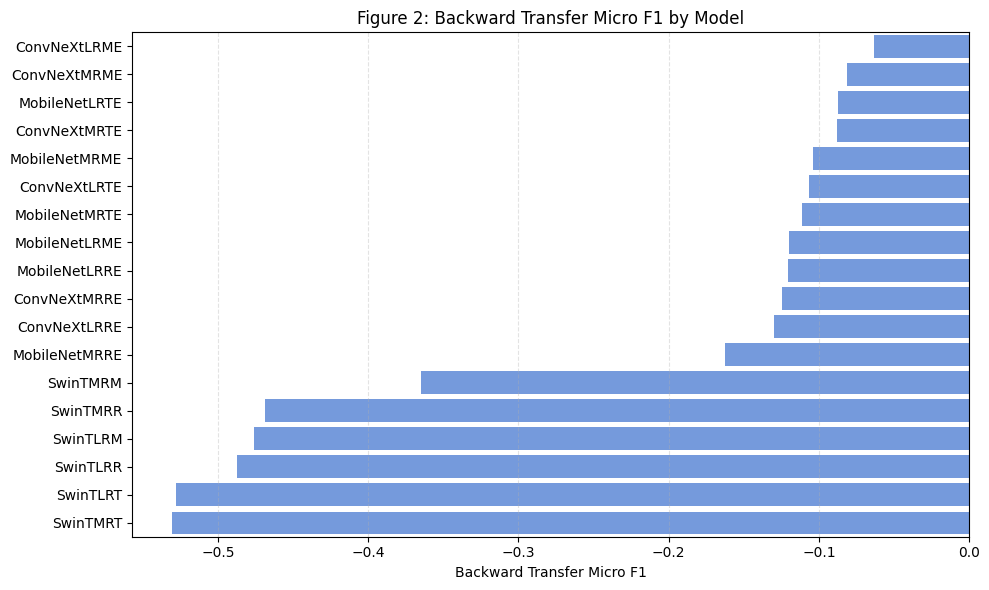

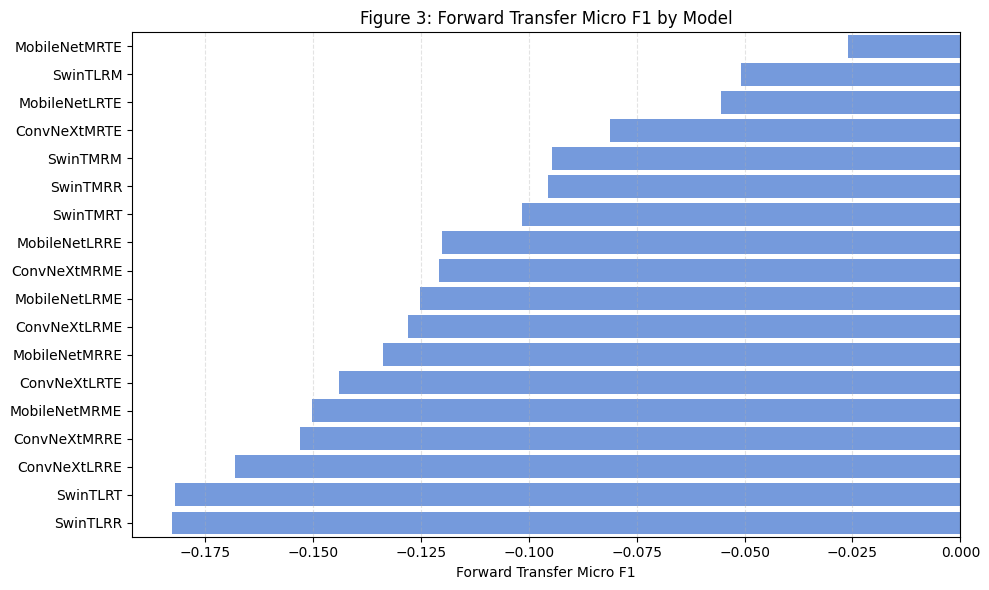

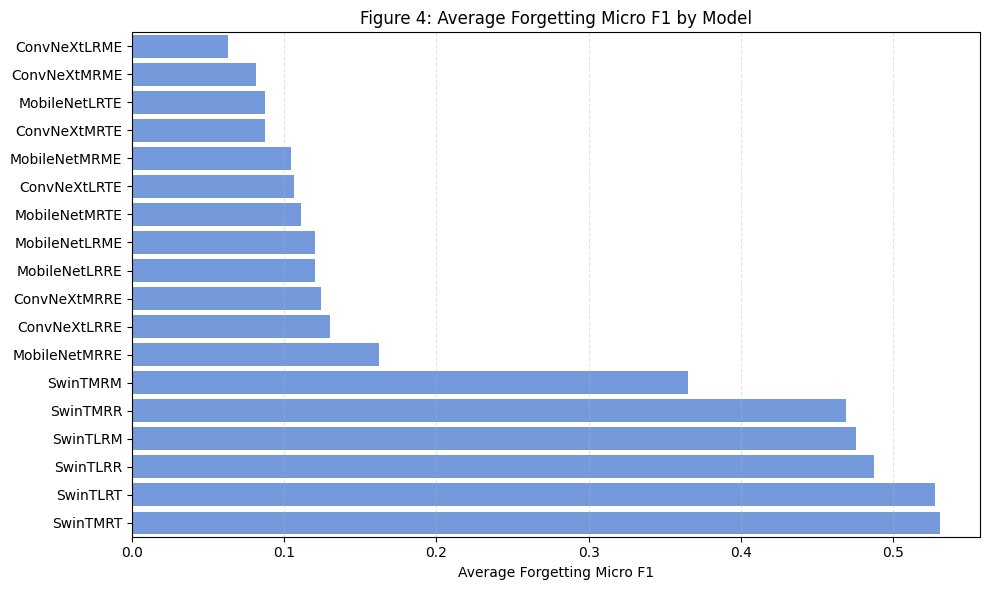

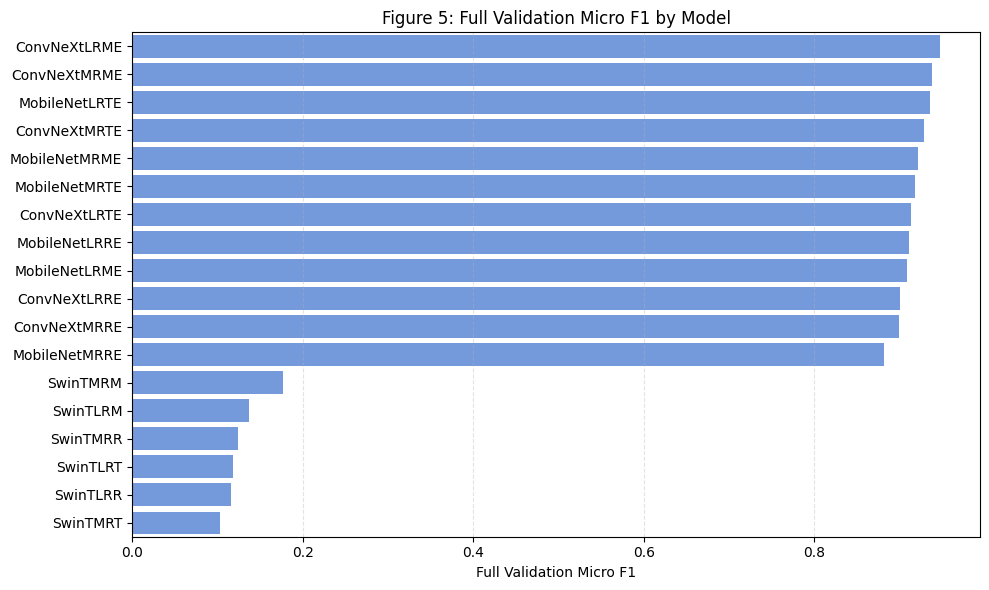

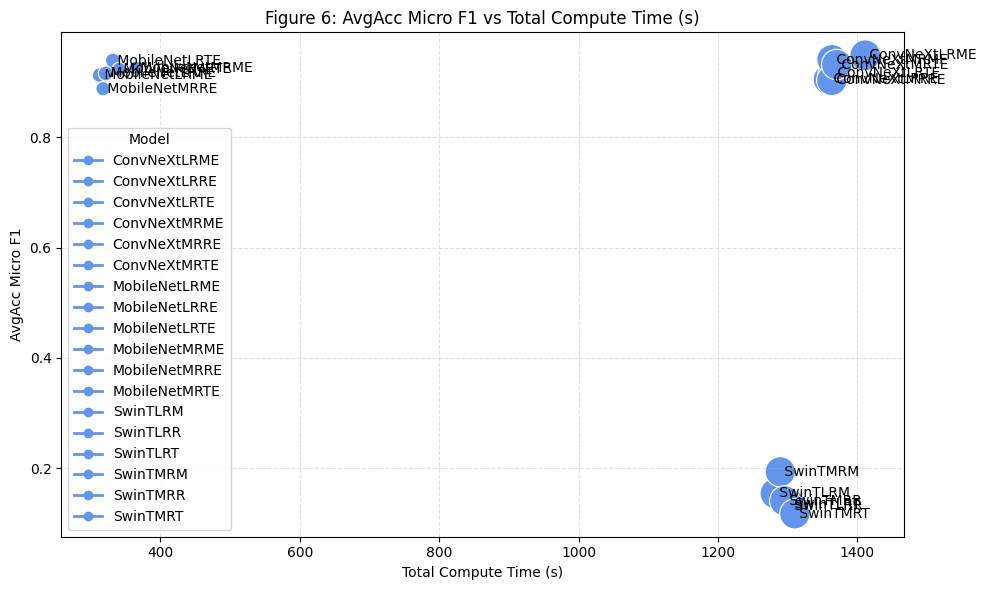

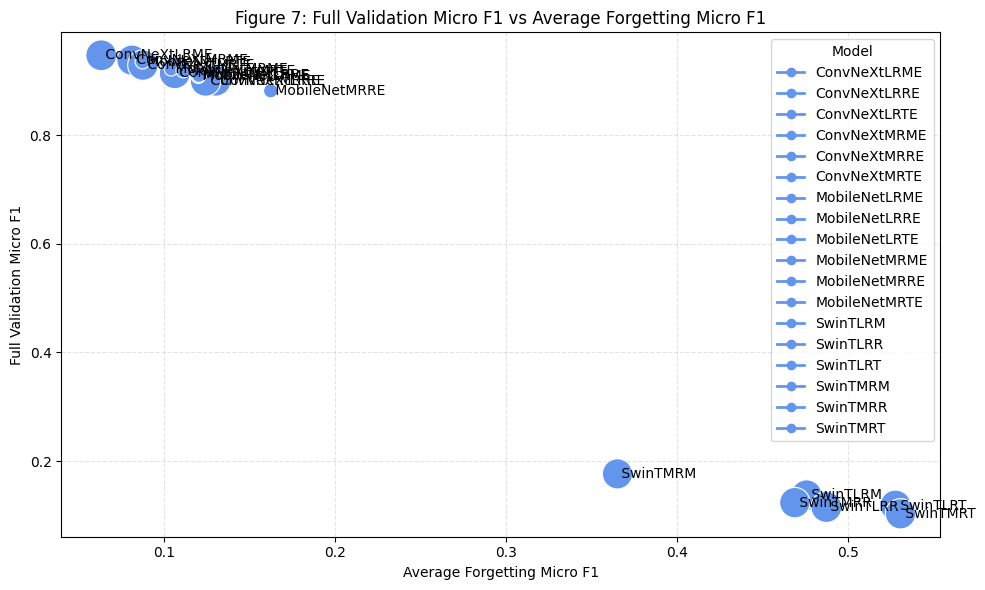

In [11]:
for metric in ['Backward Transfer Micro F1', 'Forward Transfer Micro F1', 'Average Forgetting Micro F1', 'Full Validation Micro F1']:
    if metric in comparison_df.columns:
        ascending = metric == 'Average Forgetting Micro F1'
        plot_metric_bar(comparison_df, metric, ascending=ascending)

if {'Total Compute Time (s)', 'AvgAcc Micro F1'}.issubset(comparison_df.columns):
    plot_metric_scatter(comparison_df, 'Total Compute Time (s)', 'AvgAcc Micro F1', size_metric='Num Parameters')

if {'Average Forgetting Micro F1', 'Full Validation Micro F1'}.issubset(comparison_df.columns):
    plot_metric_scatter(comparison_df, 'Average Forgetting Micro F1', 'Full Validation Micro F1', size_metric='Num Parameters')

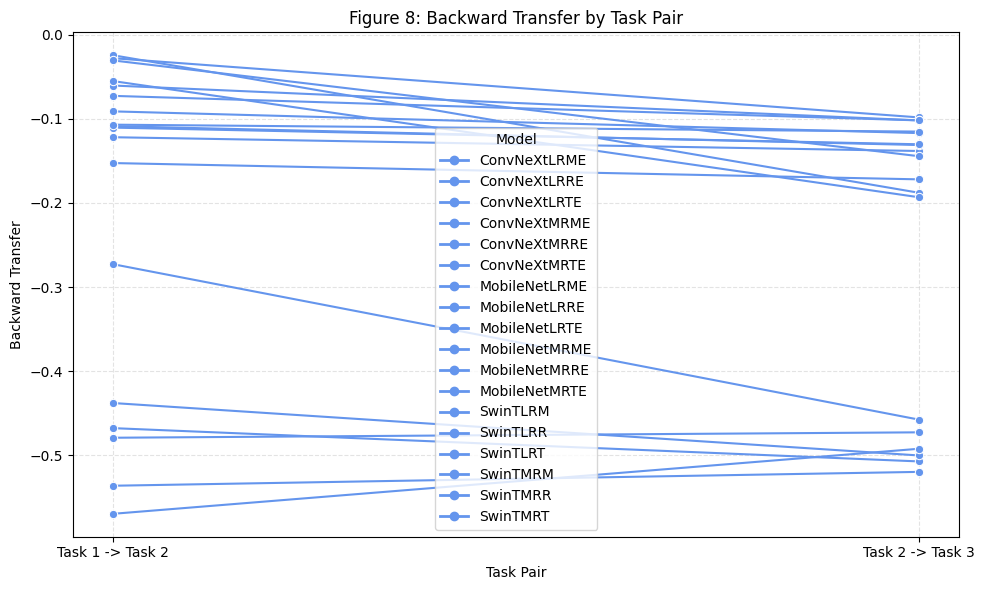

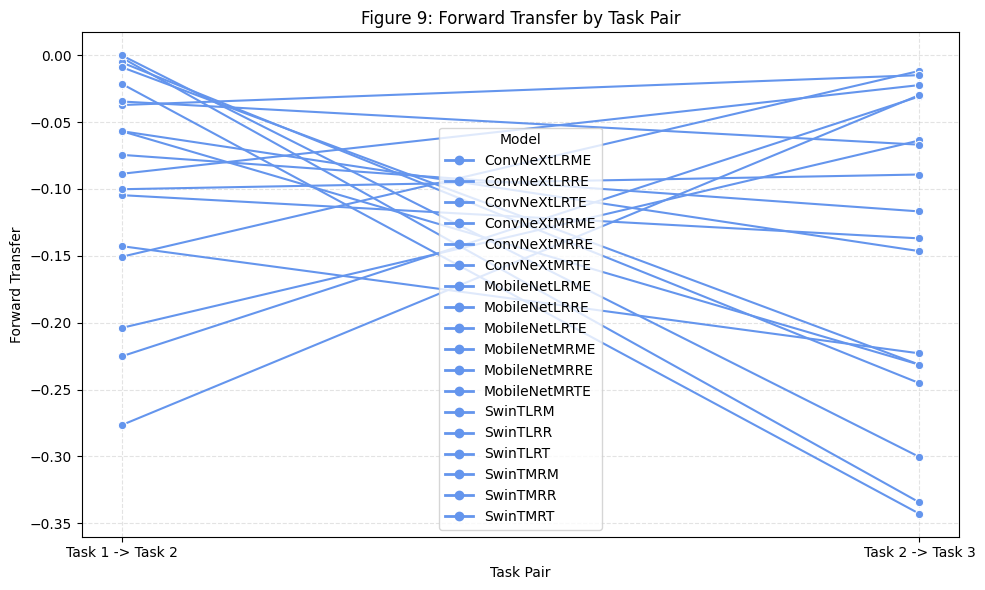

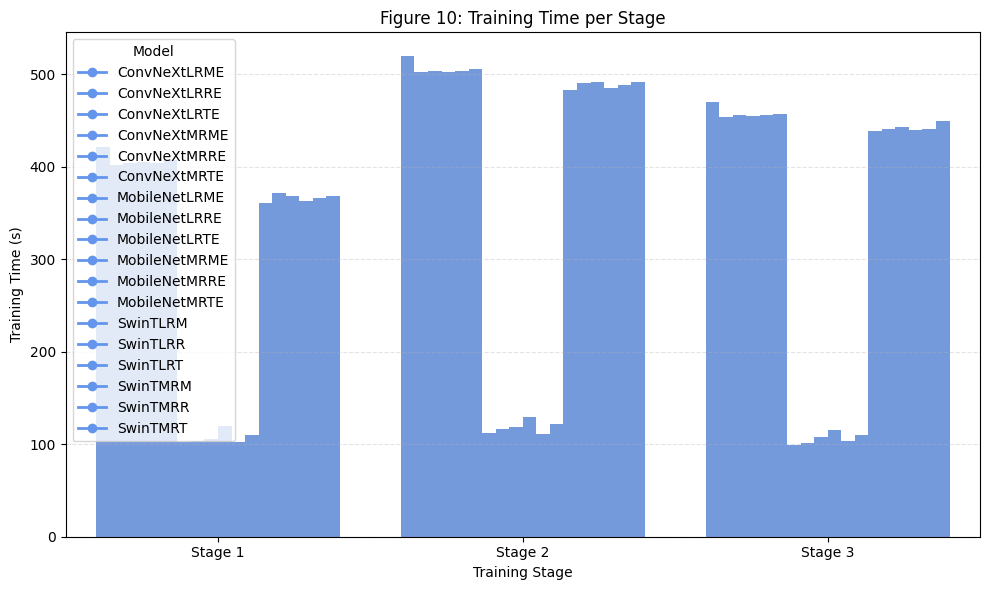

In [12]:
if not transfer_df.empty:
    plot_transfer_curves(transfer_df, 'Backward Transfer')
    plot_transfer_curves(transfer_df, 'Forward Transfer')

if not training_time_df.empty:
    plot_training_time_per_stage(training_time_df)

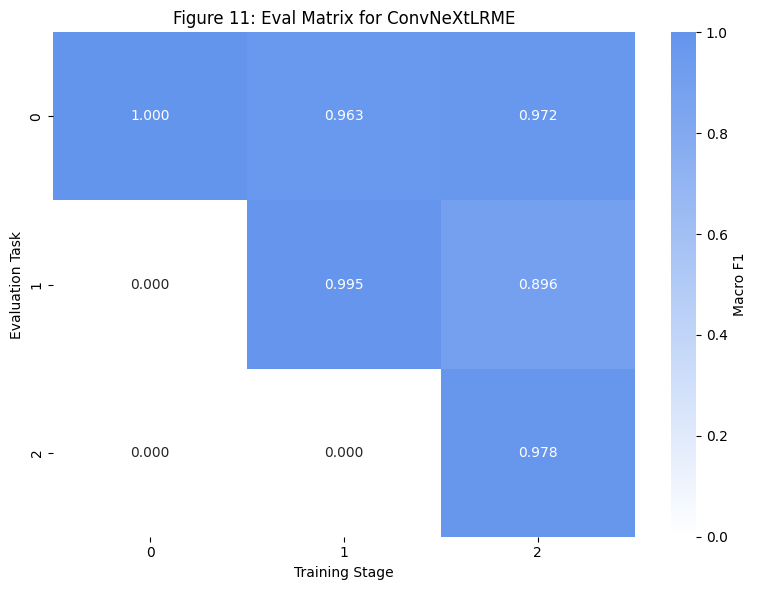

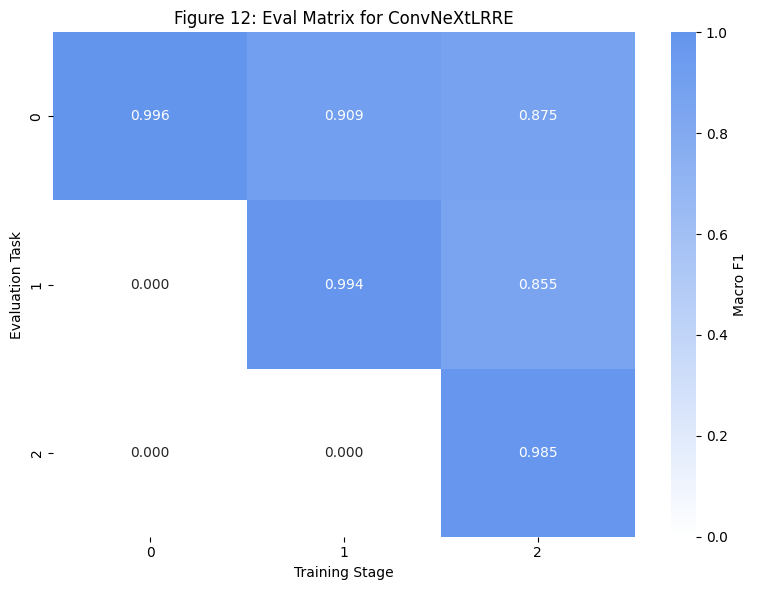

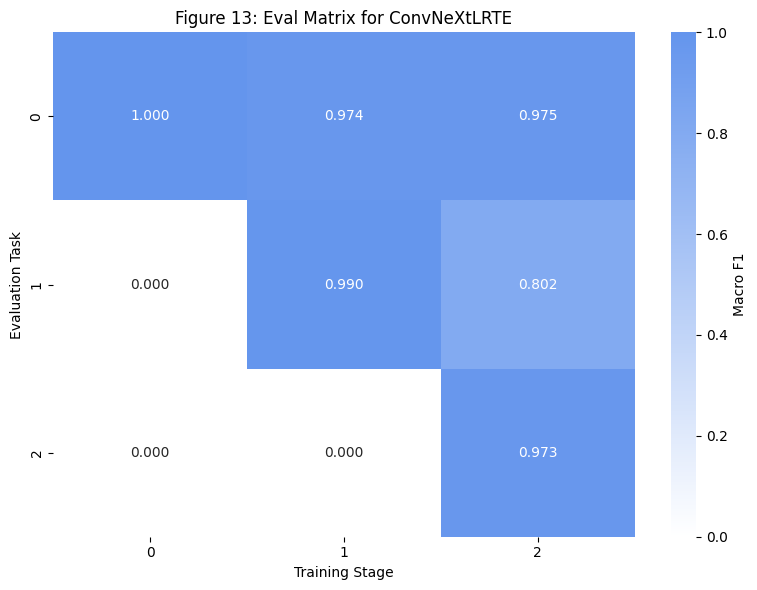

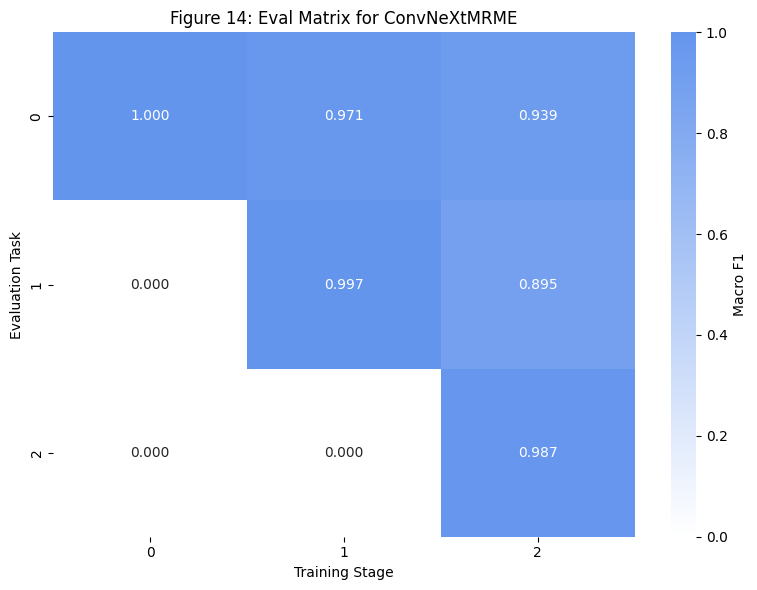

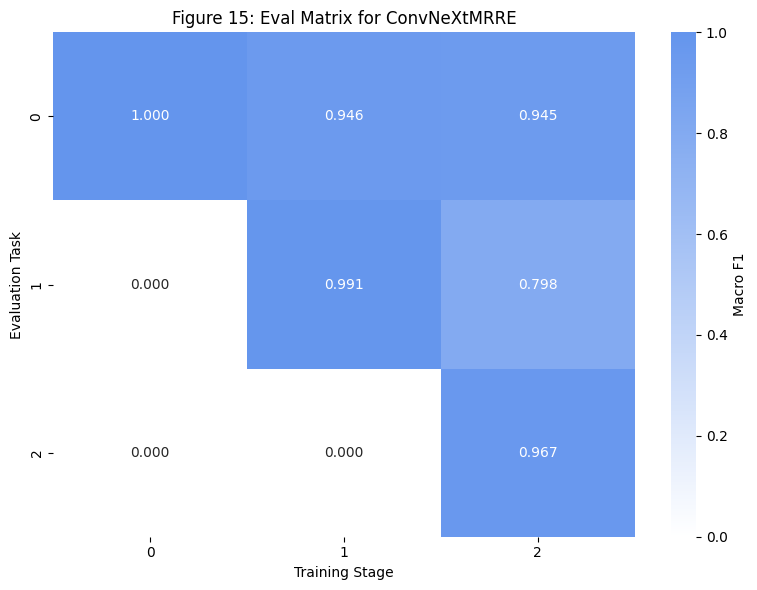

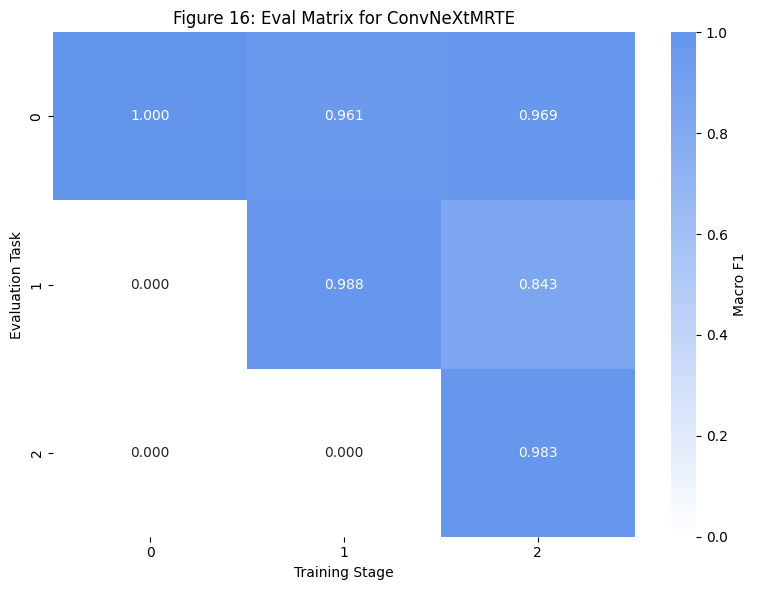

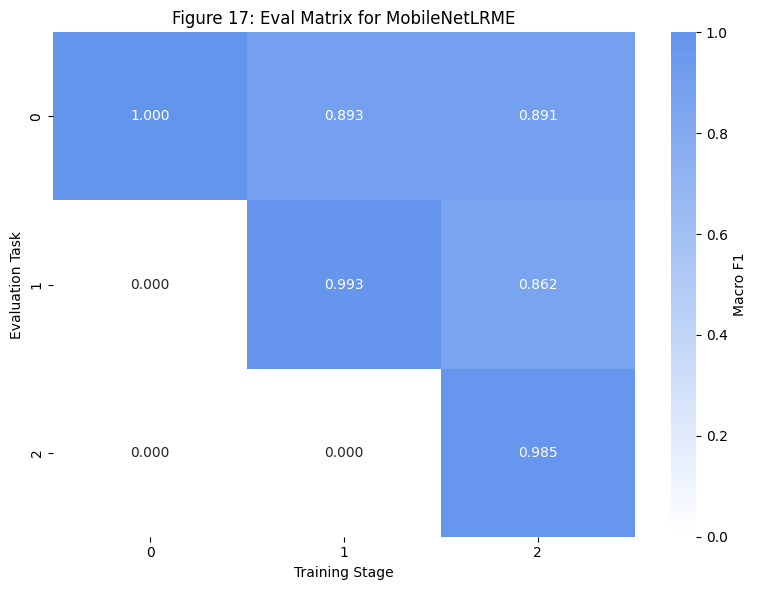

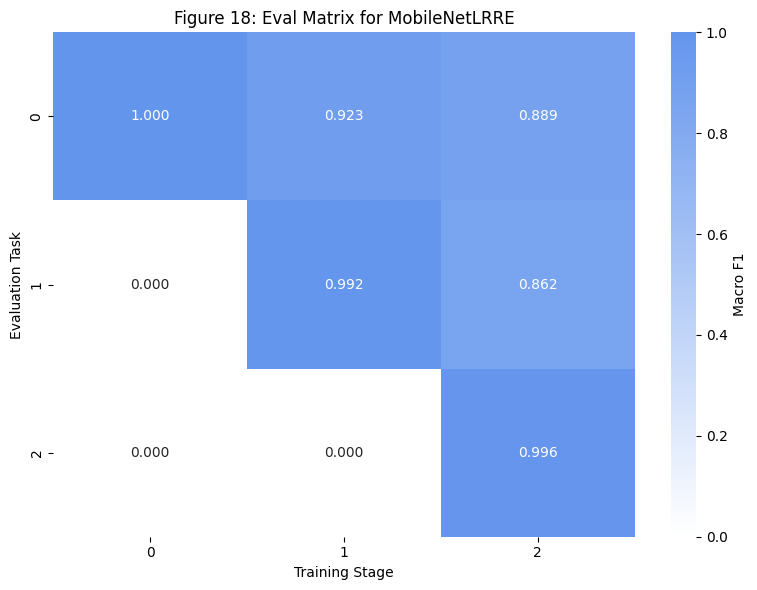

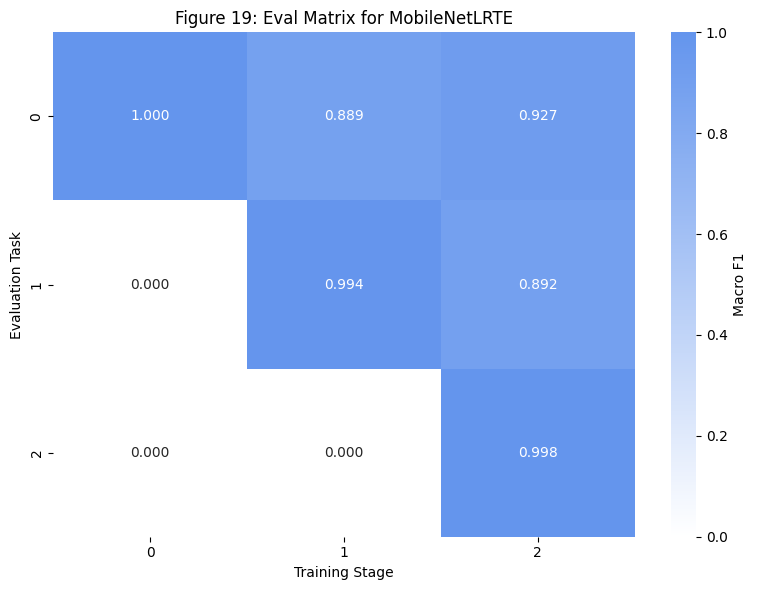

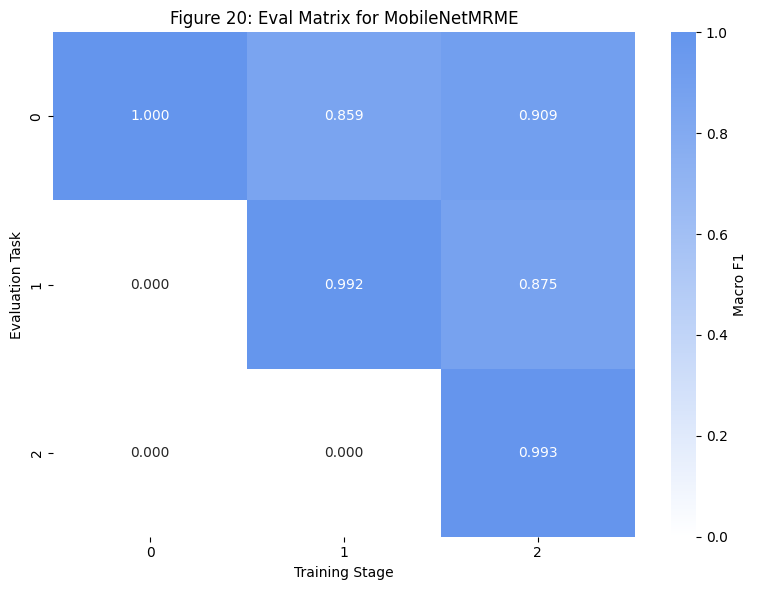

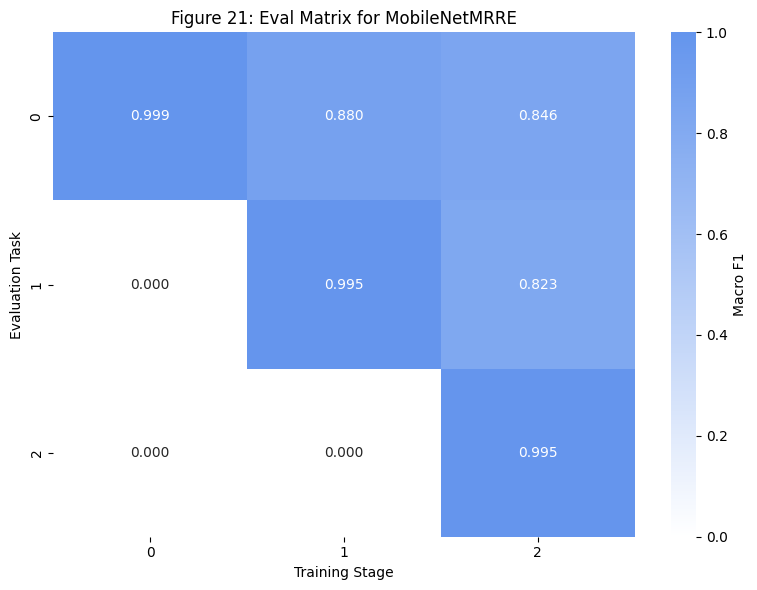

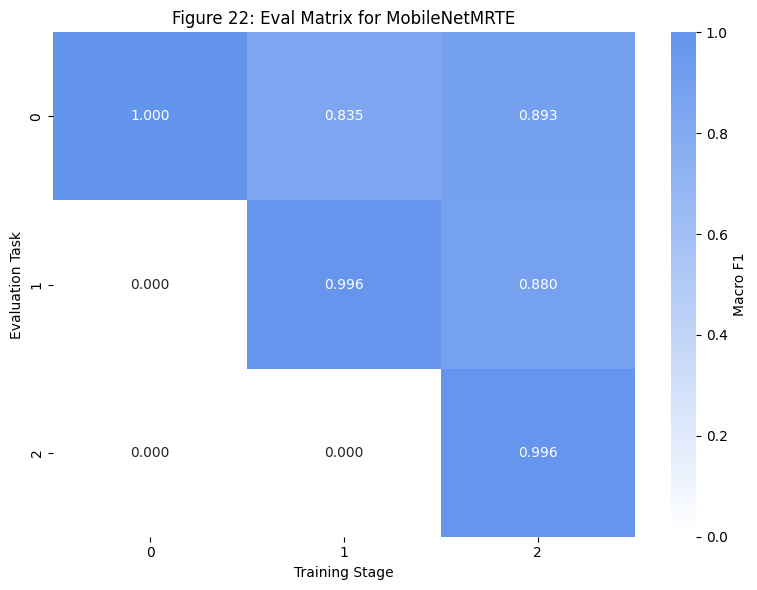

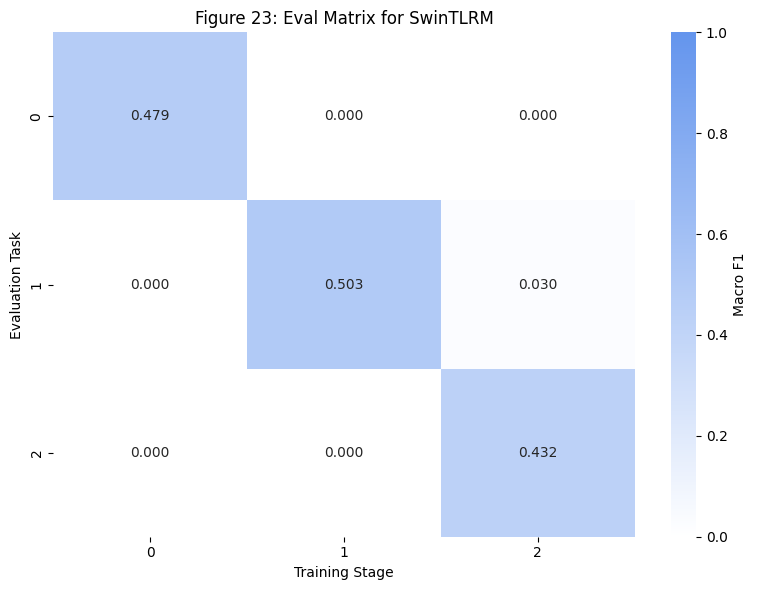

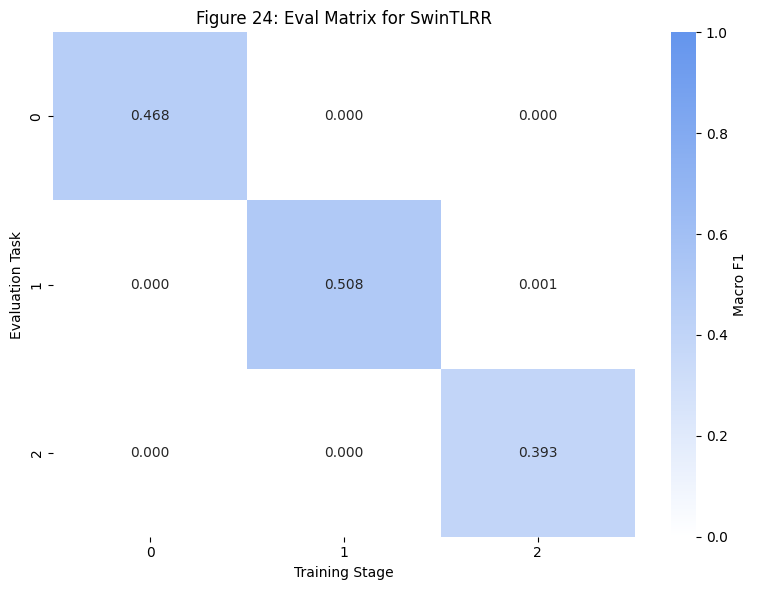

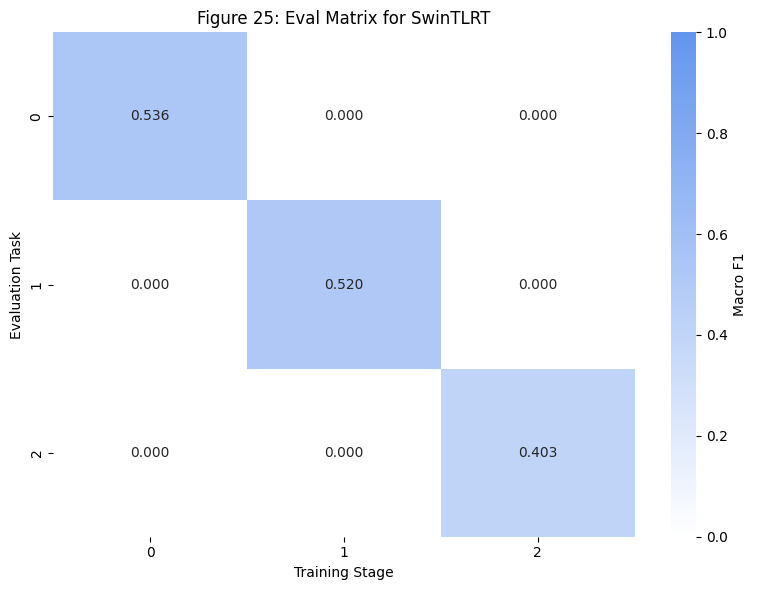

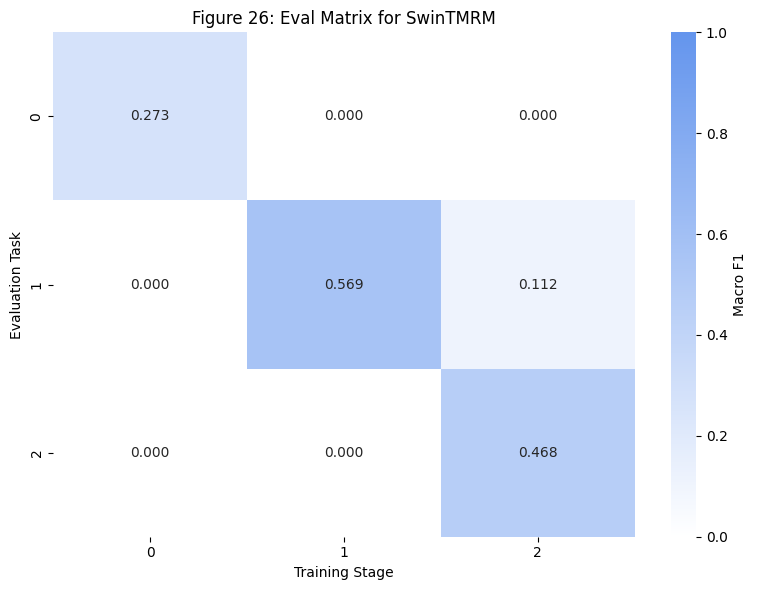

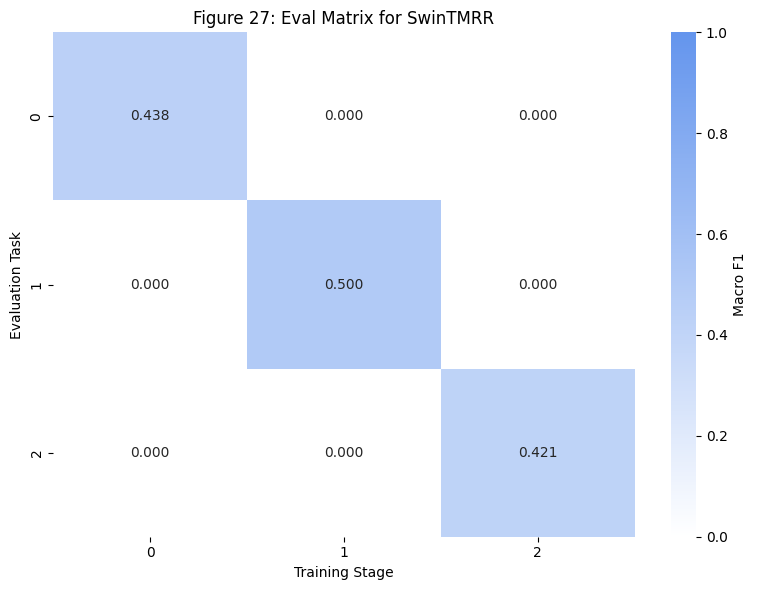

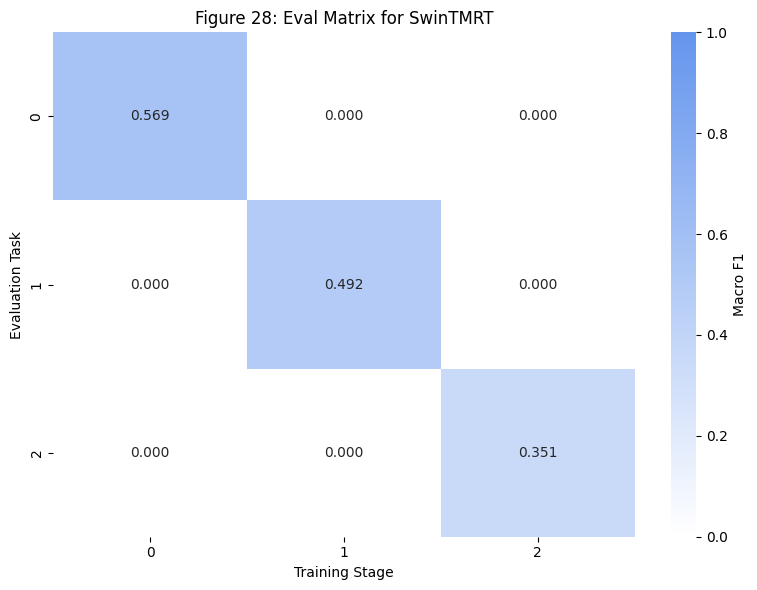

In [13]:
for run in runs:
    if 'Eval Matrix Micro F1' in run.get('results', {}):
        run_copy = dict(run)
        run_copy['eval_mat'] = np.asarray(run['results']['Eval Matrix Micro F1'], dtype=float)
        plot_eval_matrix_heatmap(run_copy)
    else:
        plot_eval_matrix_heatmap(run)